In [1]:
# HealthGuard AI - Heart Disease EDA
# Author: HealthGuard AI Team
# Date: 2026
# Purpose: Exploratory Data Analysis of Heart Disease Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')

print("=" * 50)
print("   HealthGuard AI - Heart Disease EDA")
print("=" * 50)
print("Libraries Loaded Successfully!")

   HealthGuard AI - Heart Disease EDA
Libraries Loaded Successfully!


In [2]:
# Load Heart Disease Dataset
# Source: Cleveland Clinic Foundation / Kaggle
# Records: 1025 patients, 14 columns

df = pd.read_csv("E:/HealthGuard_AI/data/raw/heart.csv")

print("Dataset Loaded Successfully!")
print("=" * 50)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print("=" * 50)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst 5 Rows:")
df.head()

Dataset Loaded Successfully!
Total Rows: 1025
Total Columns: 14

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First 5 Rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Basic Dataset Information
# Check data types and memory usage

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)
df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# Basic Statistical Analysis

print("=" * 50)
print("BASIC STATISTICS")
print("=" * 50)
df.describe().round(2)

BASIC STATISTICS


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00,1025.00
mean,54.43,0.70,0.94,131.61,246.00,0.15,0.53,149.11,0.34,1.07,1.39,0.75,2.32,0.51
std,9.07,0.46,1.03,17.52,51.59,0.36,0.53,23.01,0.47,1.18,0.62,1.03,0.62,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,48.00,0.00,0.00,120.00,211.00,0.00,0.00,132.00,0.00,0.00,1.00,0.00,2.00,0.00
50%,56.00,1.00,1.00,130.00,240.00,0.00,1.00,152.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,275.00,0.00,1.00,166.00,1.00,1.80,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


In [5]:
# Check Missing Values

print("=" * 50)
print("MISSING VALUES CHECK")
print("=" * 50)

print("NaN Values:")
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {total_missing}")

if total_missing == 0:
    print("No Missing Values Found! Dataset is Clean.")

MISSING VALUES CHECK
NaN Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total Missing Values: 0
No Missing Values Found! Dataset is Clean.


In [6]:
# Check Duplicate Rows

print("=" * 50)
print("DUPLICATE CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates Removed!")
    print(f"New Shape: {df.shape}")
else:
    print("No Duplicates Found!")

DUPLICATE CHECK
Total Duplicate Rows: 723
Duplicates Removed!
New Shape: (302, 14)


TARGET DISTRIBUTION
Heart Disease Distribution:
target
1    164
0    138
Name: count, dtype: int64

No Heart Disease: 45.7%
Heart Disease: 54.3%


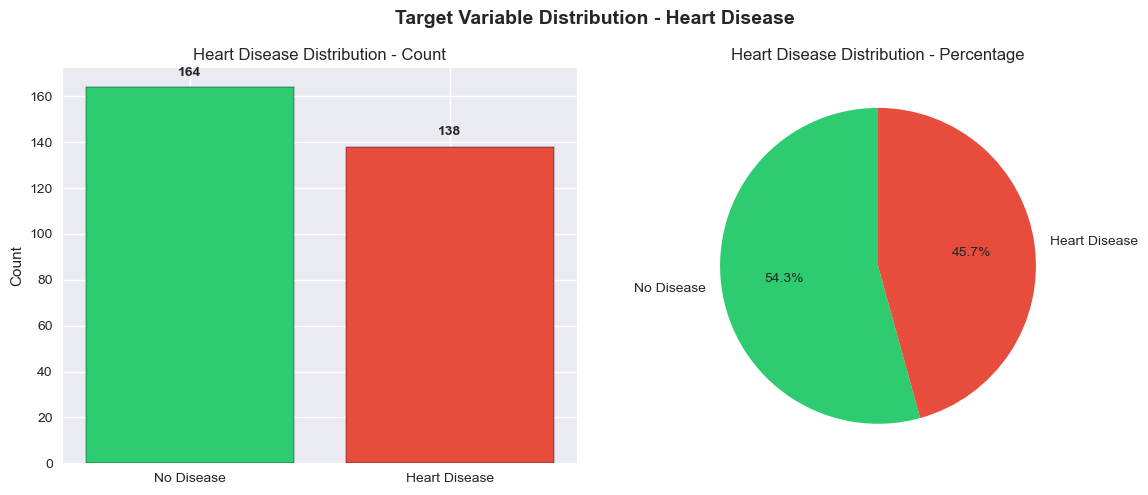

In [7]:
# Target Variable Distribution

print("=" * 50)
print("TARGET DISTRIBUTION")
print("=" * 50)

print("Heart Disease Distribution:")
print(df['target'].value_counts())

percentage = df['target'].value_counts(normalize=True) * 100
print(f"\nNo Heart Disease: {percentage[0]:.1f}%")
print(f"Heart Disease: {percentage[1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Disease', 'Heart Disease'],
            df['target'].value_counts(),
            color=['#2ecc71', '#e74c3c'],
            edgecolor='black')
axes[0].set_title('Heart Disease Distribution - Count')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(df['target'].value_counts(),
            labels=['No Disease', 'Heart Disease'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Heart Disease Distribution - Percentage')

plt.suptitle('Target Variable Distribution - Heart Disease',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

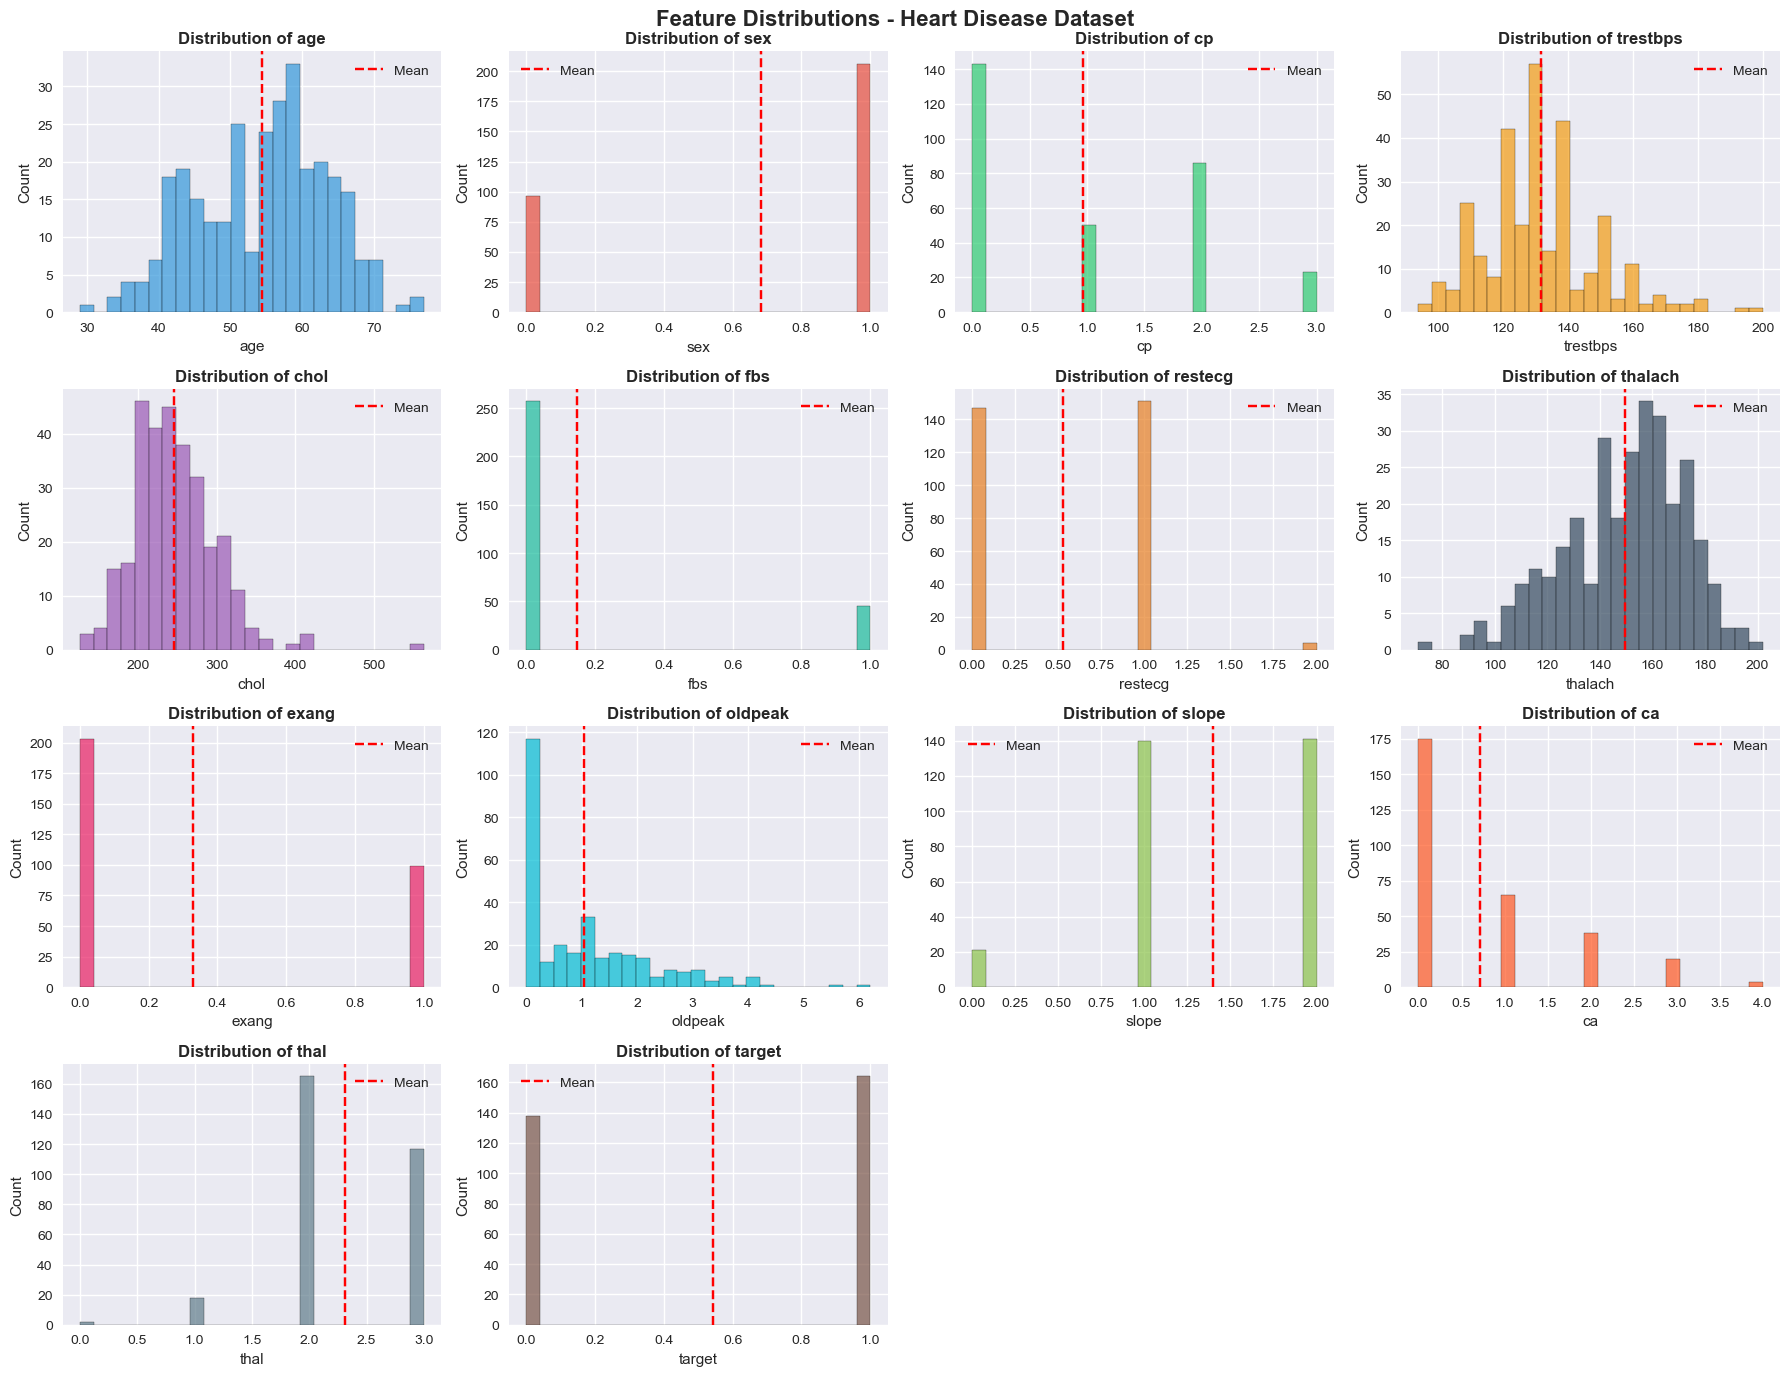

Distribution Analysis Complete!


In [8]:
# Feature Distributions

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

columns = df.columns.tolist()
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12',
          '#9b59b6', '#1abc9c', '#e67e22', '#34495e',
          '#e91e63', '#00bcd4', '#8bc34a', '#ff5722',
          '#607d8b', '#795548']

for i, col in enumerate(columns):
    axes[i].hist(df[col], bins=25,
                 color=colors[i],
                 edgecolor='black',
                 alpha=0.7)
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].axvline(df[col].mean(), color='red',
                    linestyle='--', label='Mean')
    axes[i].legend()

for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions - Heart Disease Dataset',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Distribution Analysis Complete!")

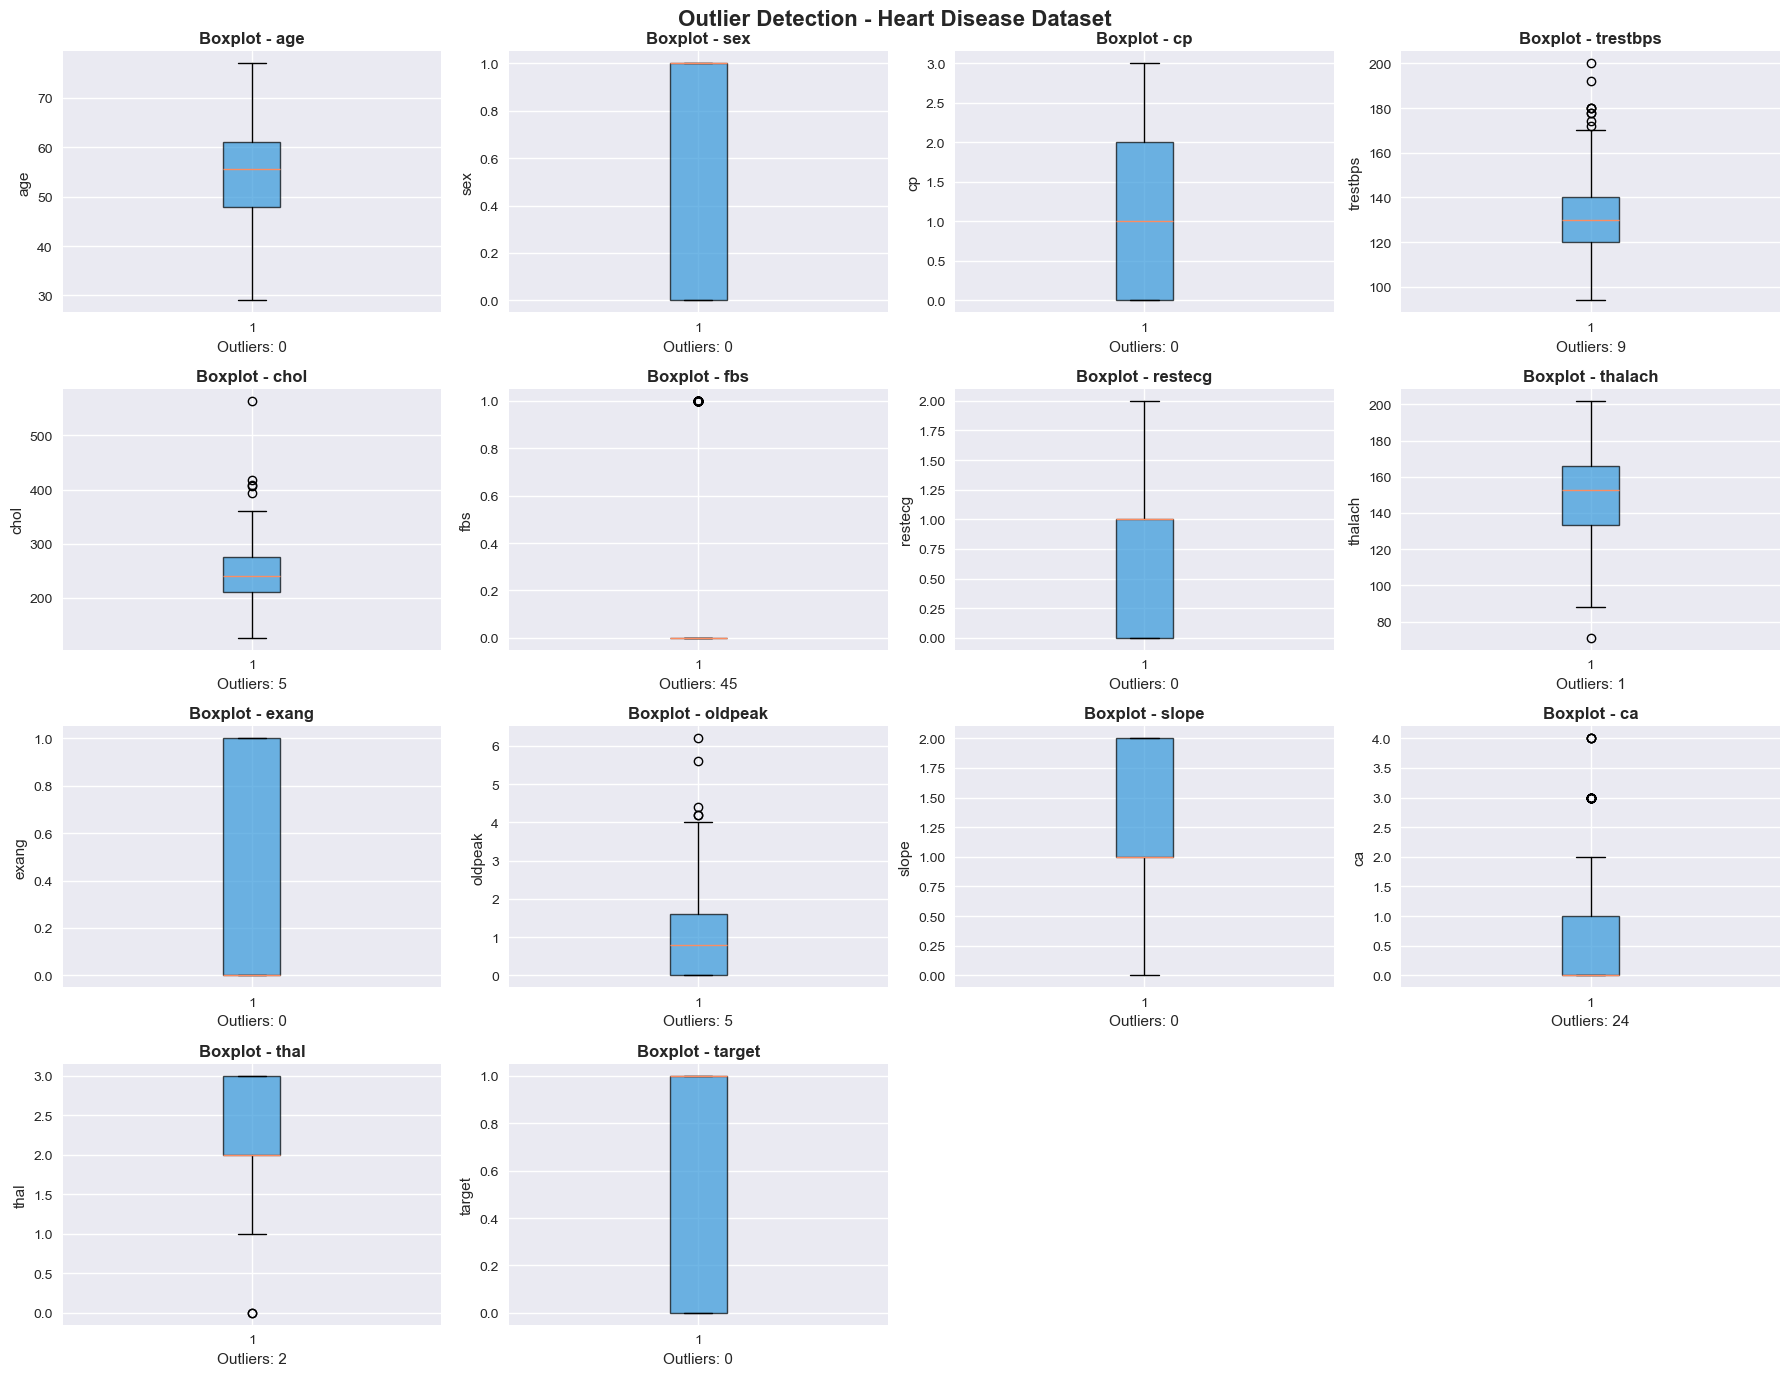

Outlier Detection Complete!


In [9]:
# Outlier Detection Using Boxplots

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

columns = df.columns.tolist()

for i, col in enumerate(columns):
    bp = axes[i].boxplot(df[col].dropna(),
                         patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][0].set_alpha(0.7)
    axes[i].set_title(f'Boxplot - {col}', fontweight='bold')
    axes[i].set_ylabel(col)

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < (Q1 - 1.5 * IQR)) |
                (df[col] > (Q3 + 1.5 * IQR))).sum()
    axes[i].set_xlabel(f'Outliers: {outliers}')

for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - Heart Disease Dataset',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Outlier Detection Complete!")

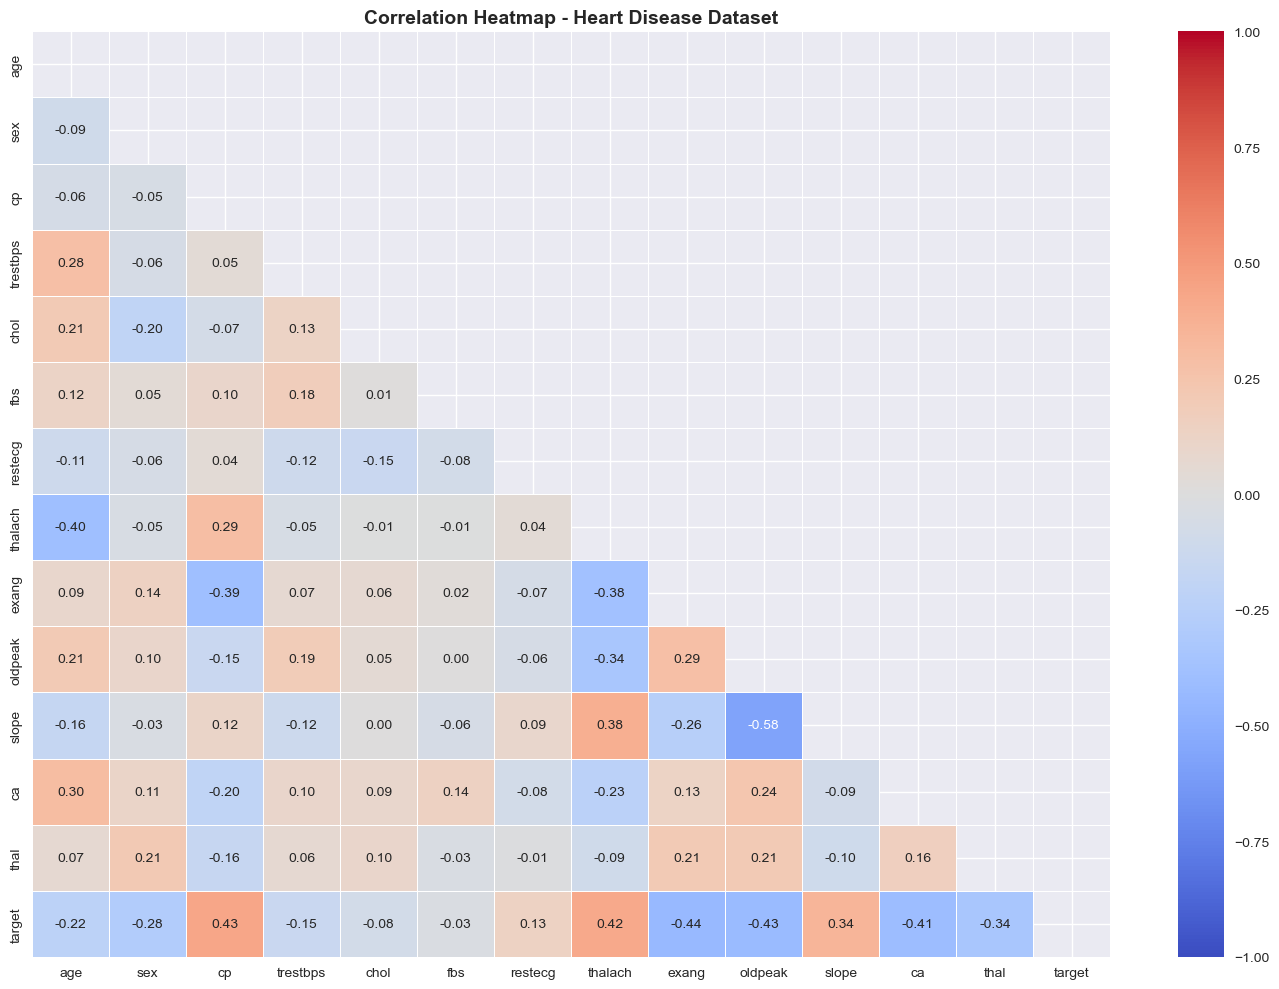

Top Correlations with Heart Disease (target):
target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


In [10]:
# Correlation Heatmap

plt.figure(figsize=(14, 10))
correlation = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(correlation, dtype=bool))

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            linewidths=0.5,
            mask=mask,
            vmin=-1, vmax=1)

plt.title('Correlation Heatmap - Heart Disease Dataset',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Top Correlations with Heart Disease (target):")
print(correlation['target'].sort_values(ascending=False))

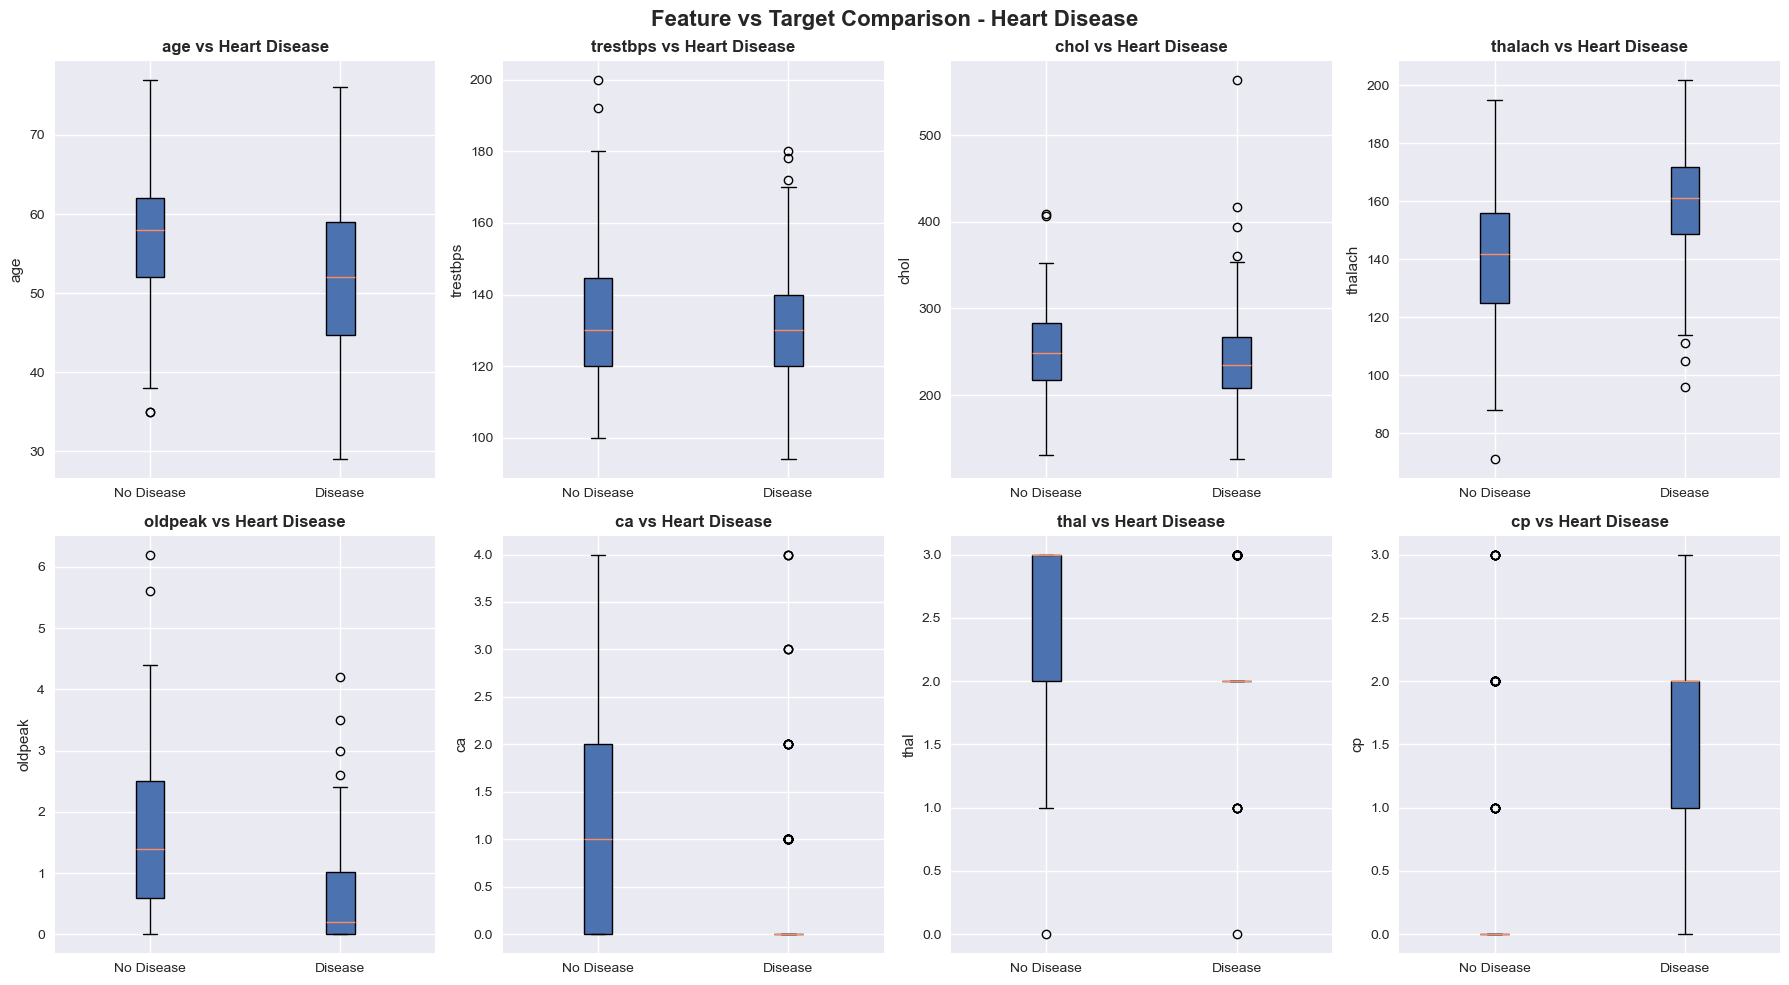

Feature vs Target Analysis Complete!


In [16]:
# Feature vs Target Analysis

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

features = ['age', 'trestbps', 'chol', 'thalach',
            'oldpeak', 'ca', 'thal', 'cp']

for i, feature in enumerate(features):
    axes[i].boxplot(
        [df[df['target']==0][feature].dropna(),
         df[df['target']==1][feature].dropna()],
        tick_labels=['No Disease', 'Disease'],
        patch_artist=True
    )
    axes[i].set_title(f'{feature} vs Heart Disease',
                      fontweight='bold')
    axes[i].set_ylabel(feature)

plt.suptitle('Feature vs Target Comparison - Heart Disease',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Feature vs Target Analysis Complete!")

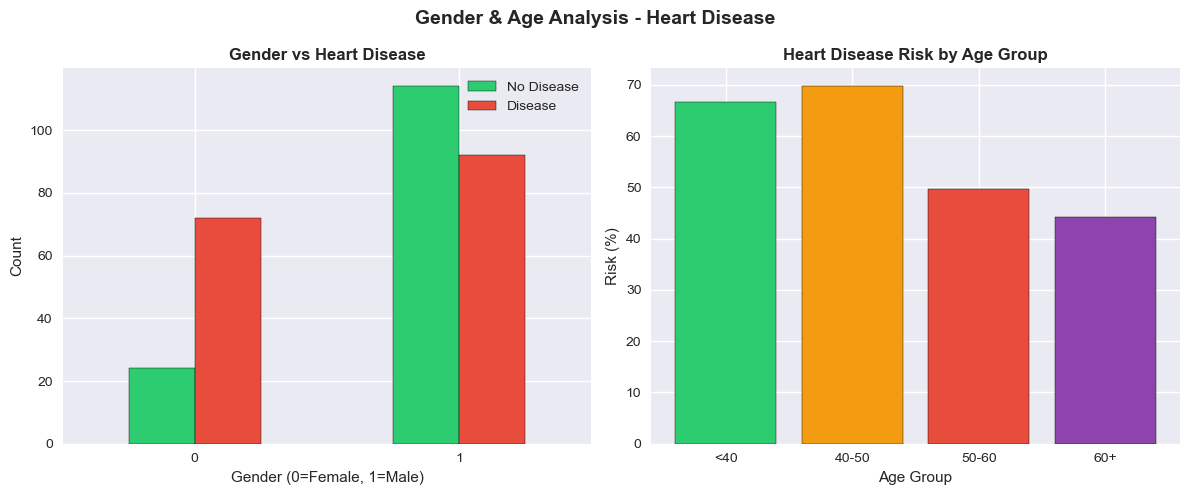

Gender & Age Analysis Complete!


In [17]:
# Gender vs Heart Disease Analysis

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

gender_counts = df.groupby(['sex', 'target']).size().unstack()
gender_counts.plot(kind='bar',
                   ax=axes[0],
                   color=['#2ecc71', '#e74c3c'],
                   edgecolor='black')
axes[0].set_title('Gender vs Heart Disease', fontweight='bold')
axes[0].set_xlabel('Gender (0=Female, 1=Male)')
axes[0].set_ylabel('Count')
axes[0].legend(['No Disease', 'Disease'])
axes[0].tick_params(rotation=0)

age_heart = df.groupby(pd.cut(df['age'],
                               bins=[0, 40, 50, 60, 100],
                               labels=['<40', '40-50',
                                       '50-60', '60+']),
                        observed=True)['target'].mean() * 100
axes[1].bar(age_heart.index,
            age_heart.values,
            color=['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad'],
            edgecolor='black')
axes[1].set_title('Heart Disease Risk by Age Group',
                  fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Risk (%)')

plt.suptitle('Gender & Age Analysis - Heart Disease',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Gender & Age Analysis Complete!")

In [15]:
# EDA Summary Report

print("=" * 60)
print("   HEART DISEASE EDA - SUMMARY REPORT")
print("=" * 60)

print(f"\nDataset Shape: {df.shape}")
print(f"Total Patients: {len(df)}")
print(f"Heart Disease: {(df['target']==1).sum()}")
print(f"No Heart Disease: {(df['target']==0).sum()}")

print("\nKEY FINDINGS:")
print("-" * 40)
print("1. Males have higher heart disease risk")
print("2. cp (chest pain) strongest predictor")
print("3. thalach (max heart rate) important feature")
print("4. Older age group has higher risk")
print("5. ca (vessels) has strong correlation")

print("\nNEXT STEPS:")
print("-" * 40)
print("1. Data Cleaning")
print("2. Feature Engineering")
print("3. Model Training")

print("\nHeart Disease EDA Complete!")
print("=" * 60)

   HEART DISEASE EDA - SUMMARY REPORT

Dataset Shape: (302, 14)
Total Patients: 302
Heart Disease: 164
No Heart Disease: 138

KEY FINDINGS:
----------------------------------------
1. Males have higher heart disease risk
2. cp (chest pain) strongest predictor
3. thalach (max heart rate) important feature
4. Older age group has higher risk
5. ca (vessels) has strong correlation

NEXT STEPS:
----------------------------------------
1. Data Cleaning
2. Feature Engineering
3. Model Training

Heart Disease EDA Complete!
